# Chocolate Sales Analysis

An exploratory data analysis of chocolate product sales across six countries 
(Australia, Canada, India, New Zealand, UK, USA) using non-parametric statistical methods.

## Objective
Identify whether sales amounts differ significantly by country or by product, 
and determine which specific products drive those differences.

## Dataset
- 3,282 sales transactions across 22 chocolate products and 6 countries
- Features: Sales Person, Country, Product, Date, Amount, Boxes Shipped

## Methods
- Data cleaning: currency parsing, type conversion
- Exploratory analysis: grouped summary statistics, boxplots
- Statistical testing: Kruskal-Wallis test for group differences
- Post-hoc analysis: pairwise Mann-Whitney U tests with Bonferroni correction

## Key Findings
- No significant difference in sales amounts across countries (Kruskal-Wallis, p = 0.73)
- Significant difference in sales amounts across products (Kruskal-Wallis, p = 0.004)
- Drinking Coco significantly underperforms relative to White Choc and Almond Choco 
  after Bonferroni correction (231 pairwise comparisons, 2 significant pairs)

## Tools
Python · pandas · scipy · matplotlib

In [1]:
import pandas as pd

In [3]:
file_path = "/Users/saiyambardia/Documents/Machine_Learning/input/chocolate-sales-dataset/Chocolate_Sales.csv"

chocolate = pd.read_csv(file_path)
print(chocolate.shape)
print(chocolate.head())
print(chocolate.columns)

(3282, 6)
     Sales Person    Country              Product        Date      Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  04/01/2022   $5,320.00   
1     Van Tuxwell      India        85% Dark Bars  01/08/2022   $7,896.00   
2    Gigi Bohling      India  Peanut Butter Cubes  07/07/2022   $4,501.00   
3    Jan Morforth  Australia  Peanut Butter Cubes  27/04/2022  $12,726.00   
4  Jehu Rudeforth         UK  Peanut Butter Cubes  24/02/2022  $13,685.00   

   Boxes Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  
Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')


In [4]:
print(chocolate.dtypes)
print("\n")
print(chocolate.isnull().sum())

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


The `Amount` column of the dataframe needs to be converted to a numeric data type as it will be important for analysis and we cannot work with object data.

In [5]:
print(chocolate.Amount.head(10))

0     $5,320.00
1     $7,896.00
2     $4,501.00
3    $12,726.00
4    $13,685.00
5     $5,376.00
6    $13,685.00
7     $3,080.00
8     $3,990.00
9     $2,835.00
Name: Amount, dtype: object


In [6]:
chocolate['Amount'] = chocolate['Amount'].str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)

In [7]:
print(chocolate.Amount.head(10))
print(chocolate.dtypes)

0     5320.0
1     7896.0
2     4501.0
3    12726.0
4    13685.0
5     5376.0
6    13685.0
7     3080.0
8     3990.0
9     2835.0
Name: Amount, dtype: float64
Sales Person      object
Country           object
Product           object
Date              object
Amount           float64
Boxes Shipped      int64
dtype: object


Let's check the unique values present in `Country` and `Product` columns

In [8]:
print(chocolate['Country'].unique())
print(chocolate['Product'].unique())

['UK' 'India' 'Australia' 'New Zealand' 'USA' 'Canada']
['Mint Chip Choco' '85% Dark Bars' 'Peanut Butter Cubes'
 'Smooth Sliky Salty' '99% Dark & Pure' 'After Nines' '50% Dark Bites'
 'Orange Choco' 'Eclairs' 'Drinking Coco' 'Organic Choco Syrup'
 'Milk Bars' 'Spicy Special Slims' 'Fruit & Nut Bars' 'White Choc'
 'Manuka Honey Choco' 'Almond Choco' 'Raspberry Choco'
 'Choco Coated Almonds' "Baker's Choco Chips" 'Caramel Stuffed Bars'
 '70% Dark Bites']


We will examine the `Amount` column by grouping it using `Country` column and apply math functions such as mean, meadian, std, count, min and max.

In [11]:
country_summary = chocolate.groupby('Country').Amount.agg(['mean','median','std','count','min','max'])
country_summary = country_summary.round(2)
print(country_summary)

                mean   median      std  count    min       max
Country                                                       
Australia    5929.18  5512.57  4086.10    615   63.0  22943.37
Canada       5863.80  4950.21  4148.89    525  210.0  19449.02
India        6057.48  4917.24  4668.59    552   28.0  26170.95
New Zealand  5864.46  5306.48  4219.01    519    7.0  21381.14
UK           6302.23  5491.34  4469.29    534    7.0  22558.88
USA          6171.06  5220.69  4753.88    537   70.0  19995.68


- mean ranges from Canada at $5,863.80 to UK at $6302.23
- std are huge compared to mean - lots of spread in every country
- medians are lower than means - the distribution is right-skewed

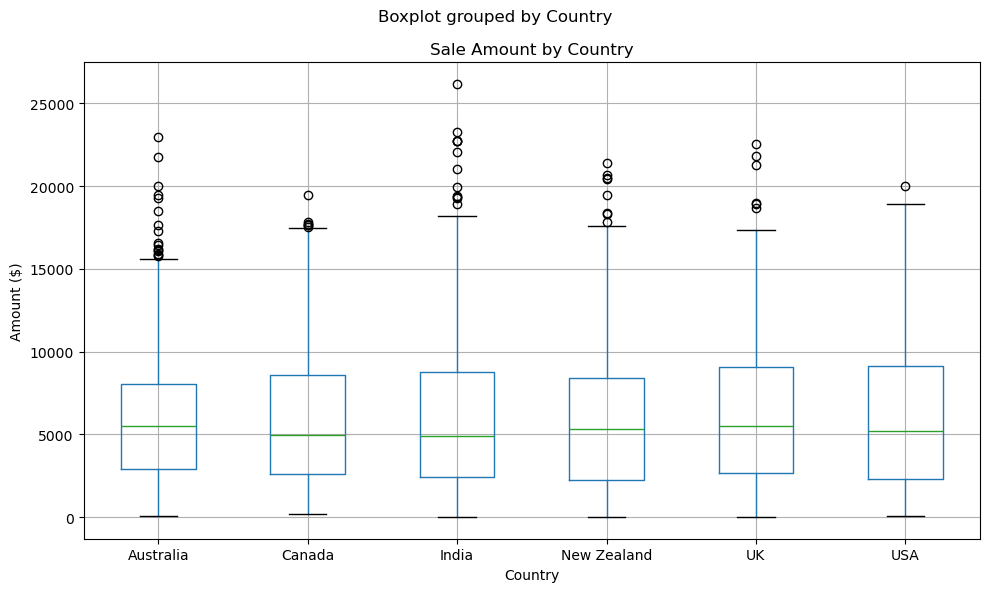

In [12]:
import matplotlib.pyplot as plt

chocolate.boxplot(column='Amount',by='Country', figsize=(10,6))
plt.title("Sale Amount by Country")
plt.xlabel('Country')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

- The plot shows that there are many outliers present.
- The median is clustered around $5000.
- Outliers scattered above every country - high-value sales pulling the mean up

In [14]:
from scipy import stats

groups = [group['Amount'].values for name, group in chocolate.groupby('Country')]

stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis stat: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference exists between countries")
else:
    print("No significant difference between countries.")

Kruskal-Wallis stat: 2.7930
p-value: 0.7319
No significant difference between countries.


There is no significant difference in sales amounts across countries. The p-value of 0.73 > 0.05, so we fail to reject the null hypothesis. Countries are preforming similarly.
\
Let's now check sales by product:

In [16]:
product_summary = chocolate.groupby('Product').Amount.agg(['mean','median','std','count','min','max'])
product_summary = product_summary.sort_values('mean', ascending=False)
print(product_summary.head(5))
print(product_summary.tail(5))

                             mean   median          std  count   min       max
Product                                                                       
Peanut Butter Cubes   7051.640068  6564.20  5263.177640    147  28.0  26170.95
Mint Chip Choco       6703.626296  5414.75  4830.808655    135  63.0  21381.14
Choco Coated Almonds  6607.375299  5532.85  4502.721775    117  49.0  18473.63
Manuka Honey Choco    6557.096519  5290.76  4635.509973    135  70.0  19995.68
99% Dark & Pure       6530.839796  5096.00  4481.380538    147   7.0  17718.25
                         mean    median          std  count    min       max
Product                                                                     
After Nines       5581.437800  4707.660  4726.064723    150   63.0  21812.86
Eclairs           5538.599778  5042.980  3607.742619    180  308.0  20690.20
Fruit & Nut Bars  5528.526400  5231.845  4153.077557    150  168.0  17280.98
70% Dark Bites    5375.763651  5504.210  3557.856587    126  1

Peanut Butter Cubes is at $7051 mean vs Drinking Coco is at $4,894 mean, which is a $2157 gap, more meaningful than the country.
\
Drinking coco has a very low median $3,748 but mean of $4,894 - heavily skewed.
\
Let's test if these product differences are statistically significant.

In [19]:
product_grps = [group['Amount'].values for name, group in chocolate.groupby('Product')]

stat, p_value = stats.kruskal(*product_grps)
print(f"Kruskal-Wallis stat: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference exists between countries")
else:
    print("No significant difference between countries.")


Kruskal-Wallis stat: 42.2000
p-value: 0.0040
Significant difference exists between countries


We see now that products differ significantly, which is also proven by the kruskal-wallis test. Now we will perform a post-hoc test with Bonferroni correction to find which products differ.

In [24]:
from itertools import combinations
from scipy.stats import mannwhitneyu

product = chocolate.Product.unique()
res = []

for p1, p2 in combinations(product, 2):
    group1 = chocolate[chocolate['Product']==p1]['Amount']
    group2 = chocolate[chocolate['Product']==p2]['Amount']
    stats, p = mannwhitneyu(group1, group2, alternative="two-sided")
    res.append({'Product 1':p1, 'Product 2':p2, 'p-value':p})

res_df = pd.DataFrame(res)

# Bonferroni Correction
n_comparisons = len(res_df)
res_df['p_adjusted'] = res_df['p-value'] * n_comparisons
res_df['significant'] = res_df['p_adjusted'] < 0.05

significant_pairs = res_df[res_df['significant'] == True].sort_values('p_adjusted')
print(f"Total Comparisons: {n_comparisons}")
print(f"Significant pairs after Bonferroni correction: {len(significant_pairs)}")
print("\nTop significant pairs:")
print(significant_pairs[['Product 1','Product 2','p_adjusted']].head(10))

Total Comparisons: 231
Significant pairs after Bonferroni correction: 2

Top significant pairs:
         Product 1     Product 2  p_adjusted
157  Drinking Coco    White Choc    0.010775
159  Drinking Coco  Almond Choco    0.021877


Out of 231 pairwise comparisons, only 2 survive the Bonferroni correction, and both involve Drinking Coco as underperformer. It's significantly lower than both White Choc and Almond Choco.
\
Thus, we can conclude that sales amount don't differ by country, but Drinking Coco significantly underperforms compared to White Choc and Almond Choco.

In [25]:
significant_pairs.to_csv('significant_product_pairs.csv',index = False)

product_summary.to_csv("product_summary.csv", index=False)

print("Files saved")

Files saved
